In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_breast_cancer

In [4]:
cancer = load_breast_cancer()
data = pd.DataFrame(cancer.data,columns=cancer.feature_names)
data['target'] = cancer.target

In [5]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [8]:
data.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [9]:
X = data.drop('target',axis=1)
y = data['target']

C:\Users\inter\AppData\Local\Temp\ipykernel_14136\5089408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=data ,palette=['red','green'])


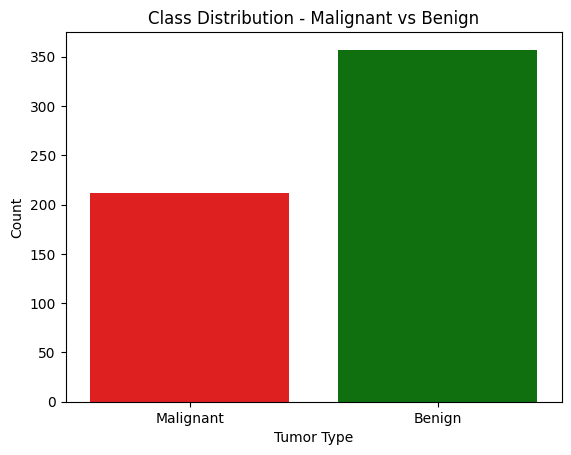

In [10]:
#Visual Graphs for understanding the data
sns.countplot(x='target',data=data ,palette=['red','green'])
plt.xticks([0,1], ['Malignant','Benign'])
plt.title('Class Distribution - Malignant vs Benign')
plt.xlabel('Tumor Type')
plt.ylabel('Count')
plt.show()


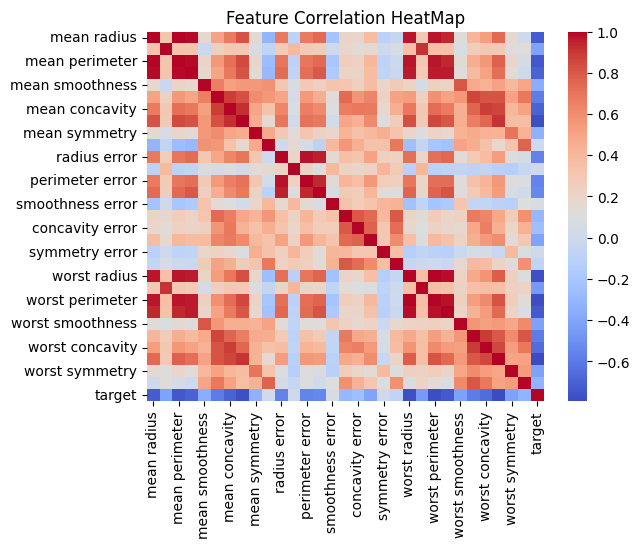

In [12]:
plt.Figure(figsize=(20,16),dpi=200)
sns.heatmap(data.corr(),annot=False,cmap='coolwarm')
plt.title('Feature Correlation HeatMap')
plt.show()

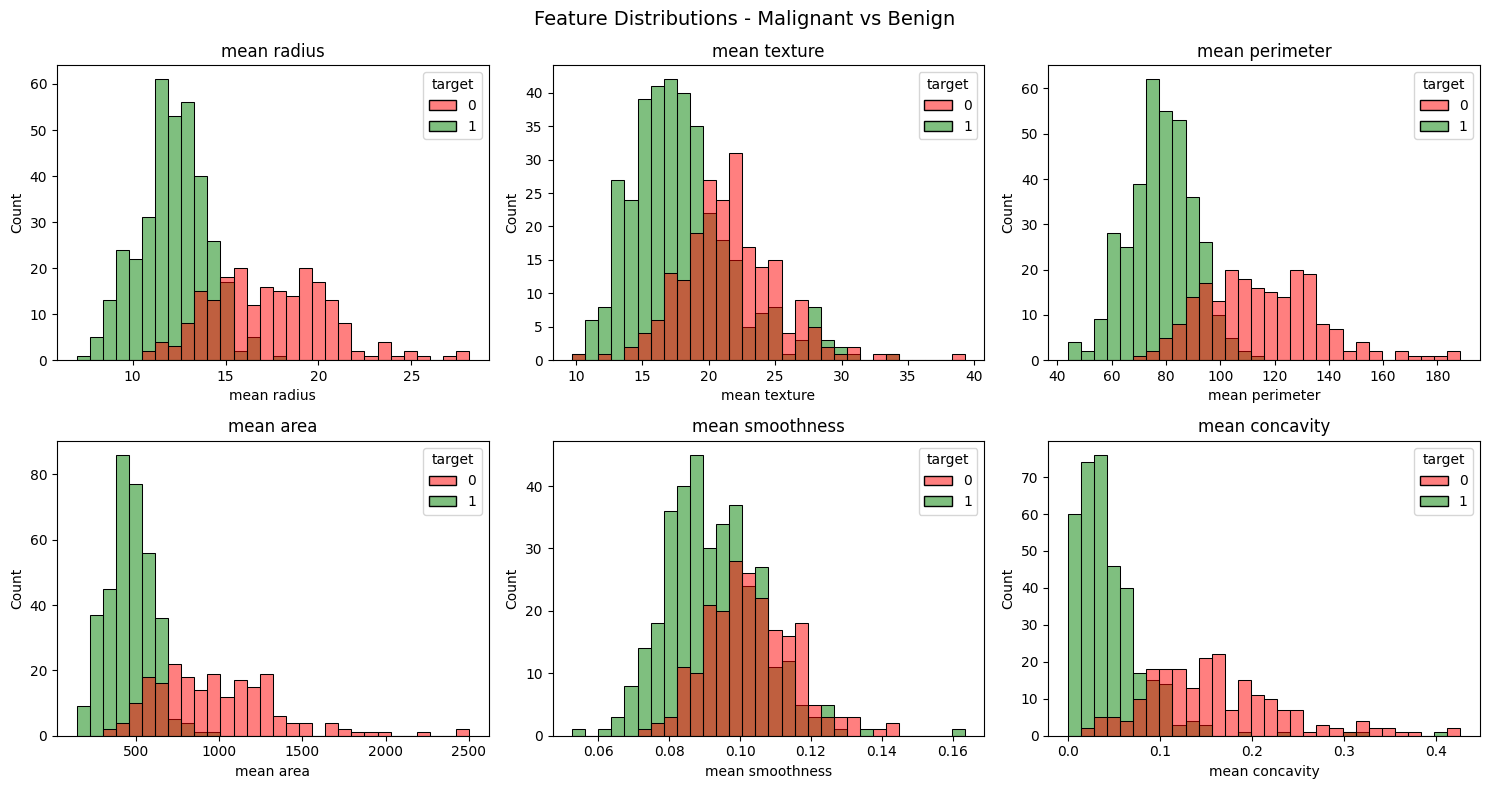

In [13]:
features = ['mean radius', 'mean texture', 'mean perimeter', 
            'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

for i, feature in enumerate(features):
    sns.histplot(
        data=data,
        x=feature,
        hue='target',
        bins=30,
        palette=['red','green'],
        ax=axes[i]
    )
    axes[i].set_title(feature)

plt.suptitle('Feature Distributions - Malignant vs Benign', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
X_train , X_test ,y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'Decision Tree' : DecisionTreeClassifier(max_depth=5),
    'Random Forest' : RandomForestClassifier(n_estimators=100 , random_state=42),
    'SVM' : SVC(kernel='rbf', probability=True),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes' : GaussianNB()
                            }

results = []

for model_name , model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred)                    , 4),
        'Precision': round(precision_score(y_test, y_pred)                   , 4),
        'Recall'   : round(recall_score(y_test, y_pred)                      , 4),
        'F1 Score' : round(f1_score(y_test, y_pred)                          , 4),
    })
    print(f"✅ {model_name} trained.")

results_df = pd.DataFrame(results)
print("\n========== MODEL COMPARISON ==========")
print(results_df.to_string(index=False))

print("\n🏆 Best Model by Accuracy:")
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"   {best['Model']} → Accuracy: {best['Accuracy']}")

print("\n🏆 Best Model by Recall:")
best_recall = results_df.loc[results_df['Recall'].idxmax()]
print(f"   {best_recall['Model']} → Recall: {best_recall['Recall']}")


✅ Logistic Regression trained.
✅ Decision Tree trained.
✅ Random Forest trained.
✅ SVM trained.
✅ KNN trained.
✅ Naive Bayes trained.

========== MODEL COMPARISON ==========
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9737     0.9722  0.9859    0.9790
      Decision Tree    0.9474     0.9577  0.9577    0.9577
      Random Forest    0.9649     0.9589  0.9859    0.9722
                SVM    0.9825     0.9726  1.0000    0.9861
                KNN    0.9474     0.9577  0.9577    0.9577
        Naive Bayes    0.9649     0.9589  0.9859    0.9722

🏆 Best Model by Accuracy:
   SVM → Accuracy: 0.9825

🏆 Best Model by Recall:
   SVM → Recall: 1.0


 In medical ML → RECALL is more important than Accuracy

Recall = Out of all actual cancer patients,
         how many did the model correctly detect?

Missing a cancer patient (False Negative) is far more
dangerous than a false alarm (False Positive)

In [26]:
import pickle
with open('breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Model saved → breast_cancer_model.pkl")

# Save scaler (always save scaler too!)
with open('breast_cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved → breast_cancer_scaler.pkl")

# Save feature names
with open('breast_cancer_features.pkl', 'wb') as f:
    pickle.dump(list(cancer.feature_names), f)
print("✅ Features saved → breast_cancer_features.pkl")

✅ Model saved → breast_cancer_model.pkl
✅ Scaler saved → breast_cancer_scaler.pkl
✅ Features saved → breast_cancer_features.pkl


## Inference Example - Making Predictions on New Data

In [27]:
# Load the saved model, scaler, and features
with open('breast_cancer_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('breast_cancer_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('breast_cancer_features.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("✅ Model, Scaler, and Features loaded successfully!")


✅ Model, Scaler, and Features loaded successfully!


In [ ]:
# Example 1: Inference on individual test samples
print("=" * 60)
print("INFERENCE EXAMPLE 1: Predicting on Test Samples")
print("=" * 60)

# Get 5 random test samples
num_samples = 5
indices = np.random.choice(len(X_test), num_samples, replace=False)

for idx, sample_idx in enumerate(indices):
    # Get the sample
    sample = X_test[sample_idx].reshape(1, -1)
    actual_label = y_test.iloc[sample_idx]
    
    # Make prediction
    prediction = loaded_model.predict(sample)[0]
    probability = loaded_model.predict_proba(sample)[0]
    
    # Display results
    pred_label = "Benign" if prediction == 1 else "Malignant"
    actual_label_text = "Benign" if actual_label == 1 else "Malignant"
    
    print(f"\nSample {idx + 1}:")
    print(f"  Actual: {actual_label_text}")
    print(f"  Predicted: {pred_label}")
    print(f"  Malignant Probability: {probability[0]:.2%}")
    print(f"  Benign Probability: {probability[1]:.2%}")
    print(f"  ✅ Correct!" if prediction == actual_label else f"  ❌ Wrong!")
    


INFERENCE EXAMPLE 1: Predicting on Test Samples

Sample 1:
  Actual: Benign
  Predicted: Benign
  Malignant Probability: 0.00%
  Benign Probability: 100.00%
  ✅ Correct!

Sample 2:
  Actual: Benign
  Predicted: Benign
  Malignant Probability: 0.00%
  Benign Probability: 100.00%
  ✅ Correct!

Sample 3:
  Actual: Malignant
  Predicted: Benign
  Malignant Probability: 1.26%
  Benign Probability: 98.74%
  ❌ Wrong!

Sample 4:
  Actual: Malignant
  Predicted: Benign
  Malignant Probability: 0.00%
  Benign Probability: 100.00%
  ❌ Wrong!

Sample 5:
  Actual: Benign
  Predicted: Benign
  Malignant Probability: 0.00%
  Benign Probability: 100.00%
  ✅ Correct!
